
# The Farmer Problem

The Farmer Problem is the classical example of two-stage stochastic programming, illustrating decision-making under uncertainty. 

A farmer must decide how much of each crop to plant (corn, wheat, and beets) before knowing the actual yields. She knows the cost of each planting an acre of each crop $230$ \$/acre, $150$ \$/acre, $260$ \$/acre, respectively and the amount of land she can plant on, $500$ acres.

<!-- <p align="center">
  <img src="_static/farmer-setup.png" width="500">
</p> -->

To satisfy livestock feed needs, at least $200$ T of wheat and $240$ T of corn are required—either produced on the farm or purchased from a wholesaler. Any surplus can be sold at market prices: \$ $170$/T for wheat and \$ $150$/T for corn. Sugar beets can be sold at \$ $36$/T up to a $6000$ T quota, and any excess only at \$ $10$/T. 

**The challenge lies in the uncertainty in the weather.** 

The Farmer knows the yields for each of the crops ($2.5$ T/acre of wheat, $3$ T/acre of corn, $20$ T/acre of beets). Depending on the three possible weather outcomes, her yield is affected as follows: 
- good $\rightarrow \times 1.2$ yield.
- average $\rightarrow \times 1$ yield.
- bad $\rightarrow \times 0.8$ yield.

After harvesting, the Farmer can make decisions about selling crops at market prices or purchasing additional crops to meet obligations. The goal is to choose a planting strategy that maximizes **expected profit** while accounting for variability in yields.

------------------

## Modeling & Setup Using SNoGloDe


In [60]:
import snoglode as sno
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from farmer_problem import TwoStageFarmer
from typing import Tuple
tolerance_level = 1e-3

### Initializing the problem: `subproblem_creator()`

This function is a helper function for building the entire stochastic program (with complicating constraints). 
It will be invoked once per each subproblem - where we will pass it each element in the list of subproblem_names = ["good", "avg", "bad"].

This callback needs to provide the following information for each subproblem:

1. **Pyomo model** associated with that particular scenario ($s{\in}[good,avg,bad]$)
2. **Complicating constraints mapping** (a dictionary, where each key dictates *which* complicating variable we are using, and each value is the associated Pyomo variable within that model.)
3. **Probability** (in stochastic programming, it is common to have a probabiliy associated with each scenario)

The complicating constraints map is defined used a Python dictionary, with the goal of capturing the relationship defined by the complicating constraints. We need to determine *which* variables, across subproblems, need to be equated to one another. In this case, it will be each of the planting decisions based on crop:

<p align="center">
  <img src="../../docs/_static/farmer-cc-map.png" width="600">
</p>

We can see how this is defined in the `subproblem_creator()` callback:

In [61]:
def subproblem_creator(scenario_name):
    """
    Based on the scenario, generates 
        1) the pyomo model
        2) the dict of complicating variable IDS : pyo.Var
        3) probability of subproblem
    and returns as a list in this order.
    """
    name_to_yield_map = {
        "good": 1.2,
        "fair": 1.0,
        "bad": 0.8
    }
    
    # create parameters / model stored in obj for this scenario
    farmer_scenario = TwoStageFarmer(name_to_yield_map[scenario_name])

    # grab the list of first stage variables
    complicating_variable_ids = {("devoted_acrege", crop): farmer_scenario.model.x[crop] \
                                for crop in farmer_scenario.planting_crops}
    
    # probability of this particular scenario occuring
    scenario_probability = 1/3

    return [farmer_scenario.model,              # pyomo model corresponding to this subproblem
            complicating_variable_ids,          # complicating varID : pyo.Var dict
            scenario_probability]               # probability of this subproblem

### Initializing the solver: `SolverParameters`

This object was created to manage the customizable settings within `SNoGloDe`. There are a number of different customizable elements, as highlighted further along in this notebook. 

Consider the (minimialist) pseudocode for `SNoGloDe`. All of the elements in <font color="green">green boxes</font> are *customizable*; users can select their own objects + callback *or* write their own.

- Select node $n$ from the queue.
- Solve a lower bounding problem $\mathcal{L}(n)$ for node $n$.
- Generate a candidate solution for the complicating variables $\hat{x}_k$ at iteration $k$.
- Branching: selecting which of the complicating variables $x_i$ to branch on next.
- Branching: partitioning the variable domain of the selected variable $x_i$.

<p align="center">
  <img src="../../docs/_static/snoglode.png" width="600">
</p>

The `SolverParameters` object is used to set all of these, whether you are selecting from preset elements or inserting your own. It is passed directly to the `Solver` object within `SNoGloDe`.

The minimimum required information is:
- `subproblem_names`: set of names corresponding to each subproblem
- `subproblm_creator`: function (as defined above)
- `lb_solver`: a Pyomo solver object, invoked and available to the lower bound.
- `cg_solver`: a Pyomo solver object, invoked and available to the candidate generator (not necessarily used).
- `ub_solver`: a Pyomo solver object, invoked and available to the upper bound.

In [62]:
subproblem_names = ["good", "fair", "bad"]
params = sno.SolverParameters(subproblem_names = subproblem_names,
                              subproblem_creator = subproblem_creator,
                              lb_solver = pyo.SolverFactory("gurobi"),
                              cg_solver = pyo.SolverFactory("gurobi"),
                              ub_solver = pyo.SolverFactory("gurobi"))
params.set_bounds_tightening(False, False)

Let's also define some useful plotting functionality (for later).

In [63]:
def plot_results(solver: sno.Solver, title: str, fig_name: str, show: bool = True) -> None:
    """
    Plots the results for a single solver.

    Parameters
    ------------
    solver : sno.Solver
        The solver instance containing the results to plot.
    title : str
        The title of the plot.
    fig_name : str
        The filename to save the plot as.
    show : bool
        Whether to display the plot immediately.
    """
    plt.figure()
    num_iters = np.arange(solver.iteration)
    plt.axhline(-108390.0, color="yellow", label="optimal", linewidth=3)
    plt.plot(num_iters, solver.plotter.iter_lb, label = "lb", color="blue")
    plt.plot(num_iters, solver.plotter.iter_ub, label = "ub", color="red")
    plt.xlabel("SNoGloDe iteration")
    plt.ylabel("objective value")
    plt.ylim(-117000, -103000)   # set y-axis 
    plt.xlim(right=100)   # set y-axis 
    # plt.title(title);
    plt.legend()
    plt.savefig(fig_name, dpi=300)
    if not show:
        plt.close()

from matplotlib.lines import Line2D

def plot_combined_results(solvers: Tuple[sno.Solver], 
                          solve_names: Tuple[str], 
                          colors: Tuple[str],
                          title: str, 
                          fig_name: str,
                          show: bool = True) -> None:
    """
    Plots the combined results of multiple solvers.

    Parameters
    ------------
    solvers : [sno.Solver]
        List of solver instances containing the results to plot.
    solve_names : [str]
        List of names corresponding to each solver for labeling.
    colors : [str]
        List of colors for each solver's plot line.
    title : str
        The title of the plot.
    fig_name : str
        The filename to save the plot as.
    """
    fig, ax = plt.subplots(figsize=(9,5))

    num_iters = np.arange(max(solver.iteration for solver in solvers))
    ax.axhline(-108390.0, color="yellow", label="optimal", linewidth=3)

    # --- Upper bounds (dashed) ---
    for solver, color, label in zip(solvers, colors, solve_names):
        ax.plot(
            num_iters[:solver.iteration],
            solver.plotter.iter_ub,
            color=color,
            linestyle='--',
            linewidth=1
        )

    # --- Lower bounds (solid) ---
    for solver, color, label in zip(solvers, colors, solve_names):
        ax.plot(
            num_iters[:solver.iteration],
            solver.plotter.iter_lb,
            label=label,              # color → solver
            color=color,
            linestyle='-',
            linewidth=1
        )

    ax.set_xlabel("SNoGloDe iteration")
    ax.set_ylabel("objective value")
    ax.set_ylim(-117000, -103000)
    ax.set_xlim(right=100)
    ax.set_title(title)

    # ---------- Legend 1: Solver (color) ----------
    solver_legend = ax.legend(
        title="Solver",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    # ---------- Legend 2: Line style (meaning) ----------
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="LB"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="UB"),
    ]

    style_legend = ax.legend(
        handles=style_handles,
        # title="Bound type",
        bbox_to_anchor=(1.05, 0.65),
        loc="upper left"
    )

    # IMPORTANT: keep both legends
    ax.add_artist(solver_legend)
    fig.subplots_adjust(right=0.72)   # reserve space for legends
    plt.savefig(fig_name, dpi=300)

    if not show:
        plt.close()

----------------

## Node Queueing (`NodeQueue`)

As we maintain the tree, spawning nodes as problems are solved, the tree will more than likely have more than one *open* (i.e., unsolved) node. We store these nodes in a generic queue. Queuing strategies help us to determine which node to solve next, and can have a significant impact on runtime / convergence. Since we can only solve one node at a time, but will always spawn two (when we cannot prune by infeasibility/bound, anyways), strategically managing how we queue (or, in other words, traverse the tree) will be very important but also problem specific.

Options available in `SNoGloDe`:
- LIFO
- FIFO
- Worst-bound

Let's use the following defaults for `SNoGloDe`'s other elements (more details on these further down the page):

In [64]:
params.set_bounders(candidate_solution_finder = sno.SolveExtensiveForm,
                    lower_bounder = sno.DropNonants)
params.set_branching(selection_strategy = sno.RandomSelection,
                     partition_strategy = sno.Midpoint)

Our experiment is as follows: given the other algorithm settings, and a maximum iteration count of 100, see how well `SNoGloDe` performs.

### `QueueStrategy.lifo`


        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.036               1                           * L U      -115405.56       -108390.0         6.4725%     7015.555556               2
            0.05               2                                      -115405.56       -108390.0         6.4725%     7015.555556               3
           0.056               3           Bound                      -115405.56       -108390.0         6.4725%     7015.555556               2
           0.068               4                                      -115405.56       -108390.0         6.4725%     7015.555556               3
           0.082               5                                      -115405.56       -108390.0       

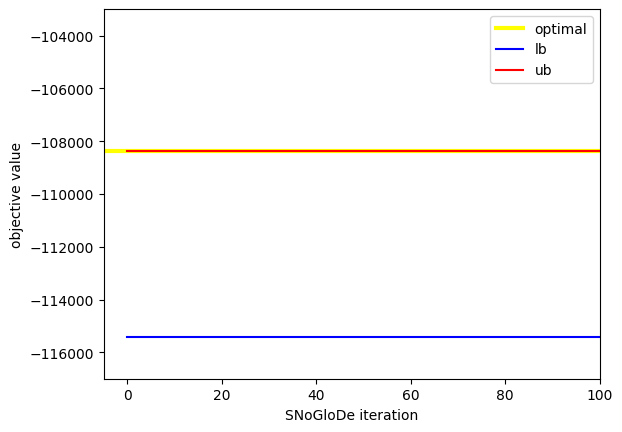

In [65]:
params.set_queue_strategy(strategy = sno.QueueStrategy.lifo)
lifo_solver = sno.Solver(params)
result = lifo_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(lifo_solver, "LIFO Queue Strategy", "figures/farmer_lifo.png")

### `QueueStrategy.fifo`

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.015               1                           * L U      -115405.56       -108390.0         6.4725%     7015.555556               2
           0.028               2                                      -115405.56       -108390.0         6.4725%     7015.555556               3
            0.04               3                                      -115405.56       -108390.0         6.4725%     7015.555556               4
           0.053               4                                      -115405.56       -108390.0         6.4725%     7015.555556               5
           0.058               5           Bound                      -115405.56       -108390.0       

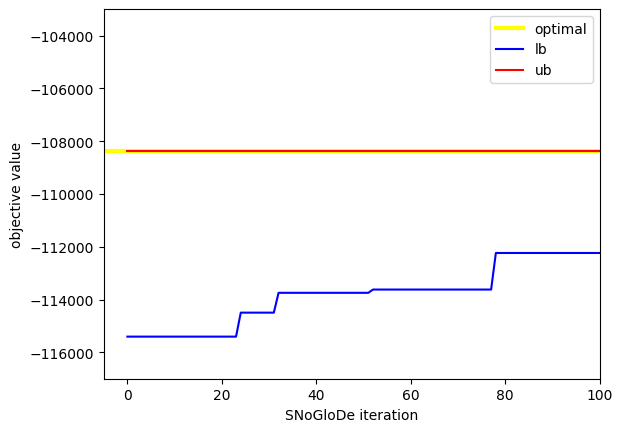

In [66]:
params.set_queue_strategy(strategy = sno.QueueStrategy.fifo)
fifo_solver = sno.Solver(params)
result = fifo_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(fifo_solver, "FIFO Queue Strategy", "figures/farmer_fifo.png")

### `QueueStrategy.bound`

This is the most commonly accepted branching methodology. The idea is as follows: to update the lower bound on the whole tree (and essentially progress the algorithm towards reaching the necessary termination condition), we have to solve the open nodes that are associated with the parent having the lowest lower bound. At the end of each iteration of the algorithm, we assign the 2 child nodes spawned from a parent a score that is equal to the parent nodes lower bound objective value. We then pop the node from the queue that has the lowest score. 


        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.015               1                           * L U      -115405.56       -108390.0         6.4725%     7015.555556               2
           0.026               2                                      -115405.56       -108390.0         6.4725%     7015.555556               3
           0.039               3                                      -115405.56       -108390.0         6.4725%     7015.555556               4
            0.05               4                                      -115405.56       -108390.0         6.4725%     7015.555556               5
           0.055               5           Bound                      -115405.56       -108390.0       

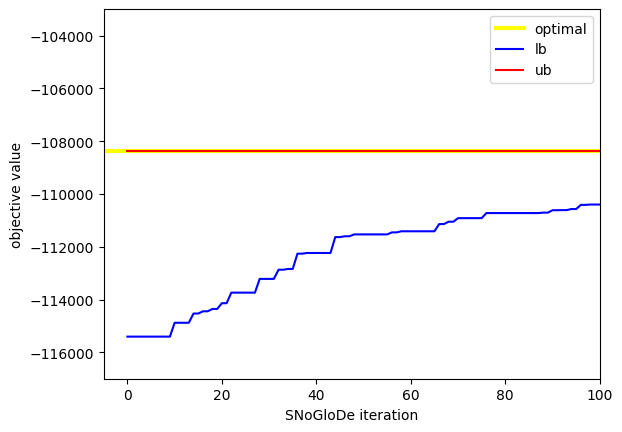

In [67]:
params.set_queue_strategy(strategy = sno.QueueStrategy.bound)
bound_solver = sno.Solver(params)
result = bound_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(bound_solver, "Best-Bound Queue Strategy", "figures/farmer_bound.png")

Just by changing the queue strategy, we can see the clear differences between 

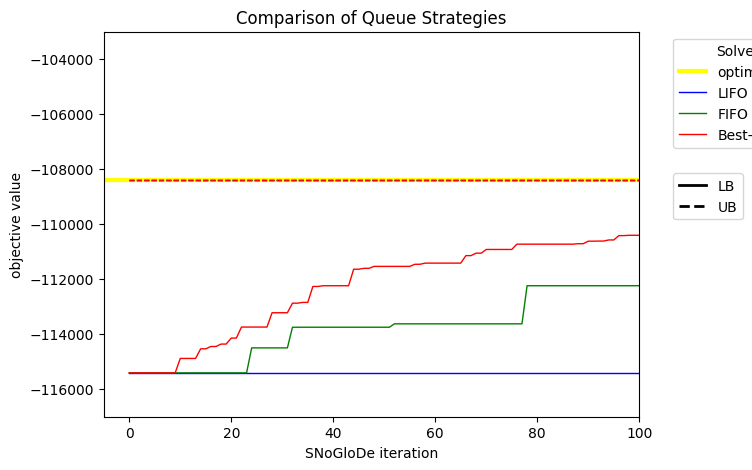

In [68]:
plot_combined_results(solvers = [lifo_solver, fifo_solver, bound_solver],
                      solve_names = ["LIFO", "FIFO", "Best-Bound"],
                      colors = ["blue", "green", "red"],
                      title = "Comparison of Queue Strategies",
                      fig_name = "figures/queue_strategies.png")

Because we used `SolveExtensiveForm` for the incumbent finder, we can see the local solution to the full problem is, in fact, the global solution (this makes sense, considering we are solving a linear program). 

What we can see, however, is a clear difference in `SNoGloDe`'s performance depending on which queue strategy is used. As expected, best bound (in red) performs the best; LIFO (in blue) doesn't produce much progress and FIFO (in green) has modest returns but nothing compared to best-bound. Once our problem had been intialized, testing each of these three different algorithms took only 9 lines of code!

---------------

## Primal/Candidate Solutions (`CandidateGenerator`)

Candidate solutions are the building blocks for the upper bound (i.e. primal) solution. We must search for feasible solutions to the optimization problem. In this case, we will accomplish this by proposing candidate solutions for the complicating variables ($\hat{x}_{beets}$, $\hat{x}_{corn}$, $\hat{x}_{wheat}$), fixing them within the optimization problems, and optimizing for the values of the non-complicating variables (selling/decisions $y$/$z$). The beauty of this is that it allows us to solve each subproblem independently! 


**The question we have to ask is: *how* do we come up with good candidate solutions?**

In `SNoGloDe`, we have two preset options:
- **`SolveExtensiveForm`**

- **`AverageLowerBoundSolution`**

Again, let's set up an experiment where we hold all other elements constant. In this case, we will use the best bound queue (because clearly, it was the best).

In [69]:
params.set_bounders(lower_bounder = sno.DropNonants)
params.set_branching(selection_strategy = sno.RandomSelection,
                     partition_strategy = sno.Midpoint)
params.set_queue_strategy(strategy = sno.QueueStrategy.bound)

### `SolveExtensiveForm(CandidateGenerator)`

The extensive form refers to the overall problem formulation where we have the complicating constraints imposed on the problem. There is nothing stopping us from trying to solve this problem directly, and using that as an incumbent solution. In general, if you can solve the extensive form, you probably don't need SNoGloDe; but consider the case of a nonlinear program where we can quickly find a locally optimal solution using a solver like Ipopt, but cannot find a globally optimal solution. This approach can prove to be very useful.

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.014               1                           * L U      -115405.56       -108390.0         6.4725%     7015.555556               2
           0.027               2                                      -115405.56       -108390.0         6.4725%     7015.555556               3
           0.038               3                                      -115405.56       -108390.0         6.4725%     7015.555556               4
            0.05               4                                      -115405.56       -108390.0         6.4725%     7015.555556               5
           0.055               5           Bound                      -115405.56       -108390.0       

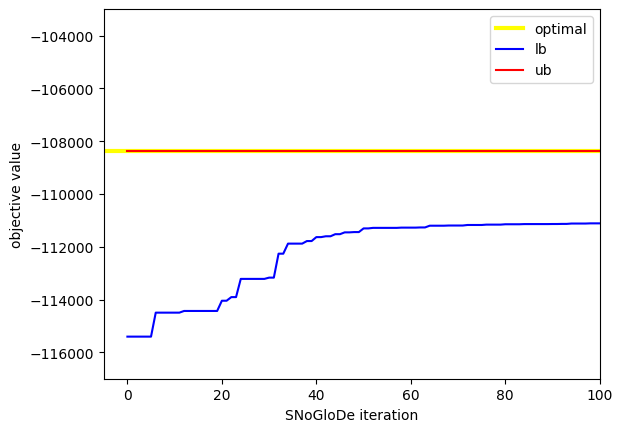

In [70]:
params.set_bounders(candidate_solution_finder = sno.SolveExtensiveForm)
ef_solver = sno.Solver(params)
result = ef_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(ef_solver, "Solve Extensive Form", "figures/farmer_ef.png")

### `AverageLowerBoundSolution(CandidateGenerator)`

At each lower bound solution, because we drop the complicating constraints, we will have a different solution for each of the complicating variables in each subproblem... so why don't we use it to our advantage? Average the solutions for all of the subproblem-specific copies of the complicating variables and test that as the primal solution.

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.013               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.024               2                                      -115405.56      -103716.67          11.27%    11688.888889               3
            0.03               3           Bound                      -115405.56      -103716.67          11.27%    11688.888889               2
           0.042               4                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.047               5           Bound                      -115405.56      -103716.67       

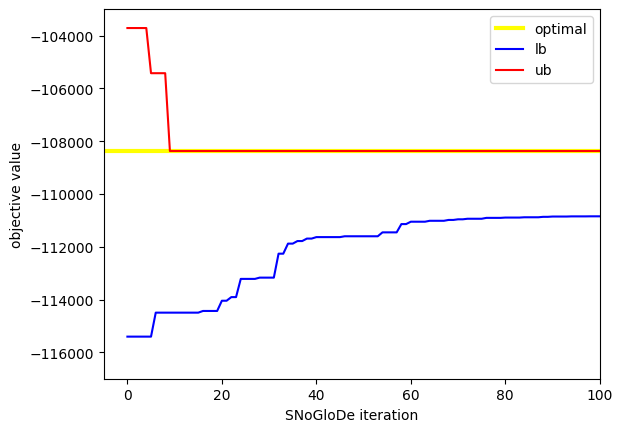

In [71]:
params.set_bounders(candidate_solution_finder = sno.AverageLowerBoundSolution)
avglb_solver = sno.Solver(params)
result = avglb_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(avglb_solver, "Average Lower Bound Solution", "figures/farmer_avglb.png")

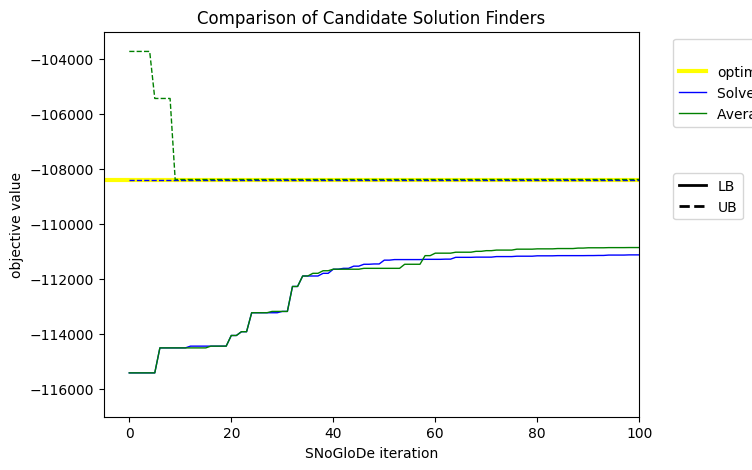

In [72]:
plot_combined_results(solvers = [ef_solver, avglb_solver],
                      solve_names = ["Solve Extensive Form", "Average Lower Bound Solution"],
                      colors = ["blue", "green"],
                      title = "Comparison of Candidate Solution Finders",
                      fig_name = "figures/candidate_solution_finders.png")

--------------------

## Branching: `SelectionStrategy`


Branching is an essential (noteably heuristic) element inherent to any branch and bound procedure. Branching is when a node, after being solved, cannot be pruned by bound (i.e., when the lower bound is higher than the current best upper bound) or by infeasibility (i.e., when the lower bound relaxation is infeasible), and is not terminal. 

To spawn a child node, we must select exactly one of the branching variables (referred to as **variable selection**). Then, we must determine where to split that variable domain (referred to as **split point selection**). 

Selection strategies refer to *how* we select the next variable to branch on, while partition strategies refer to how we *split* the selected variables domain.

In `SNoGloDe`, we offer the following for `SelectionStrategy` presets:
- **`RandomSelection`**
- **`MostInfeasibleBinary`**
- **`MaximumDisagreement`**
- **`Pseudocost`**
- **`StrongBranching`** / **`FullStrongBranching`**
- **`HybridBranching`**

Let's set up a test with the following: 

In [73]:
params.set_bounders(lower_bounder = sno.DropNonants,
                    candidate_solution_finder = sno.AverageLowerBoundSolution)
params.set_queue_strategy(strategy = sno.QueueStrategy.bound)
params.set_branching(partition_strategy = sno.Midpoint)

### `RandomSelection(SelectionStrategy)`

Out of all of the branching variables available, select one of them at random with equal probability. 


        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.012               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.022               2                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.028               3           Bound                      -115405.56      -103716.67          11.27%    11688.888889               2
           0.037               4                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.047               5                           * U        -115405.56       -106300.0       

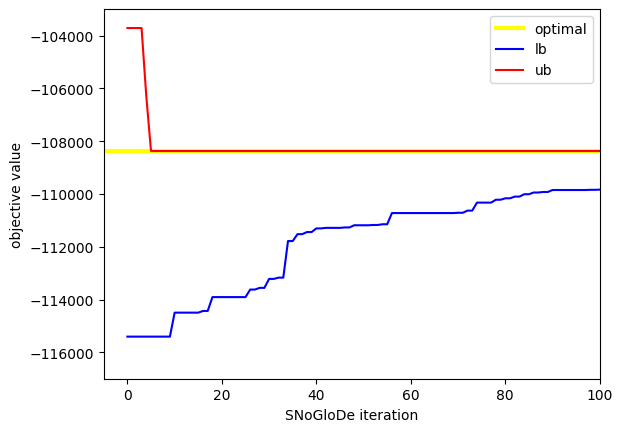

In [74]:
params.set_branching(selection_strategy = sno.RandomSelection)
random_solver = sno.Solver(params)
result = random_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(random_solver, "Random Selection", "figures/farmer_random.png")

### `MaximumDisagreement(SelectionStrategy)`

This is a generalization of Most Infeasible Binary that incorporates continuous/integer variables. In this case, we compute the normalized variance of each branching variable's solution within each subproblem (according to the lower bound). We select the variable that has the maximum normalized variance. 

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.012               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.023               2                           * U        -115405.56      -108374.44         6.4878%     7031.111111               3
           0.033               3                                      -115405.56      -108374.44         6.4878%     7031.111111               4
           0.042               4                                      -115405.56      -108374.44         6.4878%     7031.111111               5
           0.047               5           Bound                      -115405.56      -108374.44       

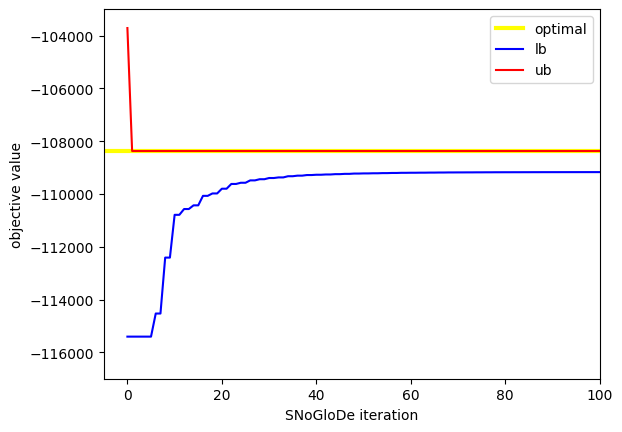

In [75]:
params.set_branching(selection_strategy = sno.MaximumDisagreement)
maxdis_solver = sno.Solver(params)
result = maxdis_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(maxdis_solver, "Maximum Disagreement", "figures/farmer_maxdis.png")

### `Pseudocost(SelectionStrategy)`

The idea is as follows: as we traverse the tree, we will inevitably branch on the same variable more than once. We can gather information about how impactful (i.e., approximate a cost) it is to branch on a variable based on the objective value change per variable delta. 

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.026               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.046               2                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.052               3           Bound                      -115405.56      -103716.67          11.27%    11688.888889               2
           0.062               4                           * U        -115405.56      -105427.22         9.4647%     9978.333333               3
           0.072               5                           * L        -114497.22      -105427.22       

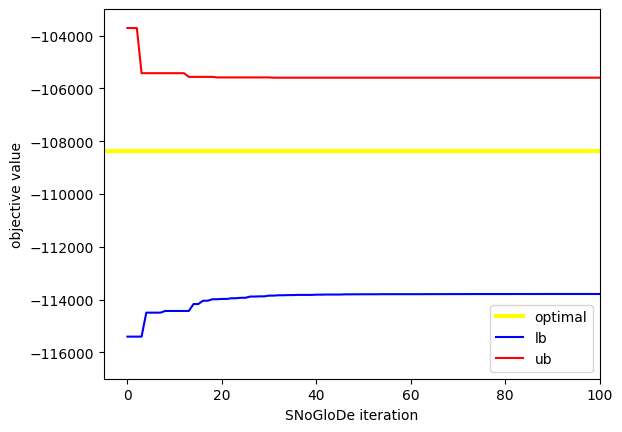

In [76]:
params.set_branching(selection_strategy = sno.Pseudocost)
pseudocost_solver = sno.Solver(params)
result = pseudocost_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(pseudocost_solver, "Pseudocost", "figures/farmer_pseudocost.png")

### `FullStrongBranching(SelectionStrategy)`

Strong branching is essentially trying to "peak" into the future while branching. 

For each branching variable $x$:

1. Generate a fully linear relaxation (i.e., relax integrality constraints and/or provide linear relaxations for nonlinear functions) for each subproblem.

2. Using the Simplex method (in this case, must have access to Gurobi, as this is what we use), perform $\eta$ number of iterations (default is 1000) for **if we branched to the right and to the left** of $x$. 

3. Record new objective values.

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
            0.05               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.098               2                           * U        -115405.56      -108374.44         6.4878%     7031.111111               3
           0.169               3                                      -115405.56      -108374.44         6.4878%     7031.111111               4
           0.228               4                                      -115405.56      -108374.44         6.4878%     7031.111111               5
           0.236               5           Bound                      -115405.56      -108374.44       

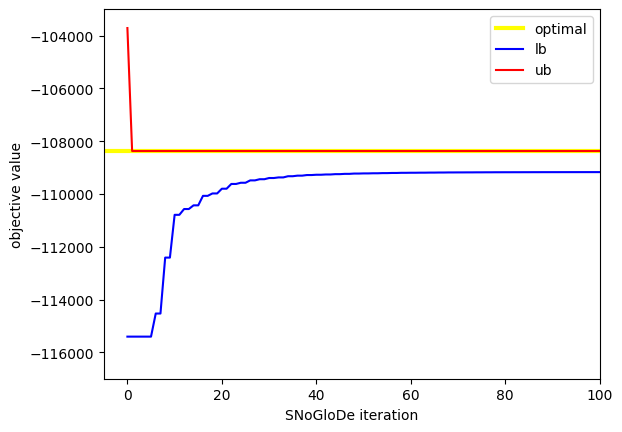

In [77]:
params.set_branching(selection_strategy = sno.FullStrongBranching)
fstrong_solver = sno.Solver(params)
result = fstrong_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(fstrong_solver, "Full Strong Branching", "figures/farmer_fstrong.png")

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.012               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.022               2                           * U        -115405.56      -108374.44         6.4878%     7031.111111               3
           0.033               3                                      -115405.56      -108374.44         6.4878%     7031.111111               4
           0.043               4                                      -115405.56      -108374.44         6.4878%     7031.111111               5
           0.047               5           Bound                      -115405.56      -108374.44       

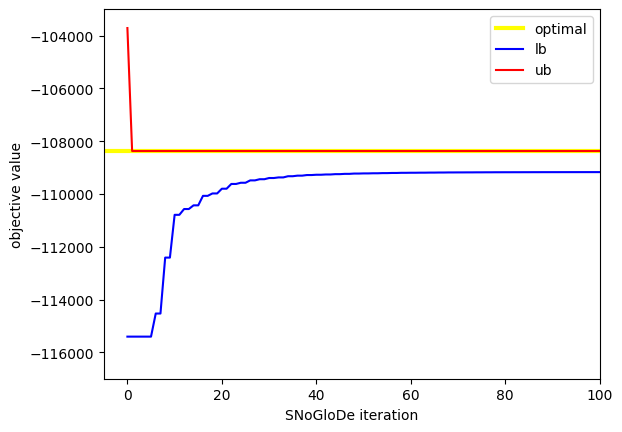

In [78]:
params.set_branching(selection_strategy = sno.HybridBranching)
hybrid_solver = sno.Solver(params)
result = hybrid_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(hybrid_solver, "Hybrid Branching", "figures/farmer_hybrid.png")

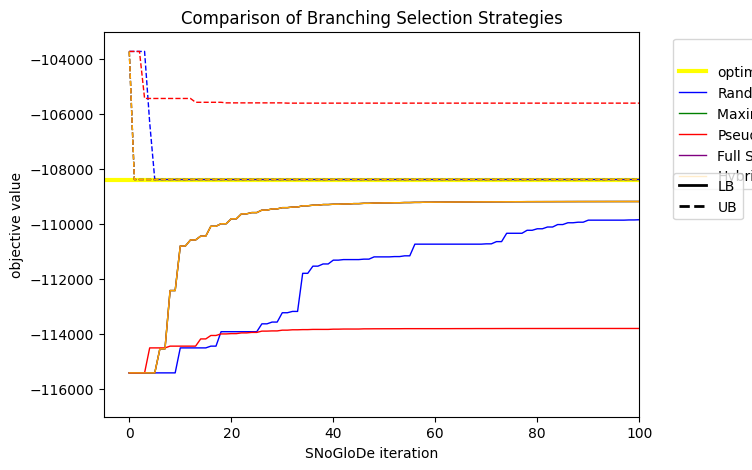

In [79]:
plot_combined_results(solvers = [random_solver, maxdis_solver, pseudocost_solver, fstrong_solver, hybrid_solver],
                      solve_names = ["Random", "Maximum Disagreement", "Pseudocost", "Full Strong Branching", "Hybrid"],
                      colors = ["blue", "green", "red", "purple", "orange"],
                      title = "Comparison of Branching Selection Strategies",
                      fig_name = "figures/branching_strategies.png")

In this case, we can see strong branching and maximum disagreement performed the best (their values are essentially overlaid on one another). Pseudocost caught up by the end, which makes sense because, as it had time to learn better costing information, it could make actual informed decisions. Random, as expected, doesn't perform particularly well. 

---------

## Branching: `PartitionStrategy`

In `SNoGloDe`, we offer the following for `PartitionStrategy` presets:
- **`Midpoint`**
- **`ExpectedValue`**

This is inherently coupled to `SelectionStrategy`; once we choose which variable to branch, we have to decide *how* to split the variable domain. The midpoint takes the current variable bounds, and splits it down the middle while expected value takes the average of all current lower bound solutions for the complicating variables.

Let's set up a test with the following: 


In [80]:
params.set_bounders(lower_bounder = sno.DropNonants,
                    candidate_solution_finder = sno.AverageLowerBoundSolution)
params.set_queue_strategy(strategy = sno.QueueStrategy.bound)
params.set_branching(selection_strategy = sno.FullStrongBranching)

### `Midpoint`

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.012               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.022               2                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.027               3           Bound                      -115405.56      -103716.67          11.27%    11688.888889               2
           0.037               4                                      -115405.56      -103716.67          11.27%    11688.888889               3
           0.047               5                           * U        -115405.56       -106300.0       

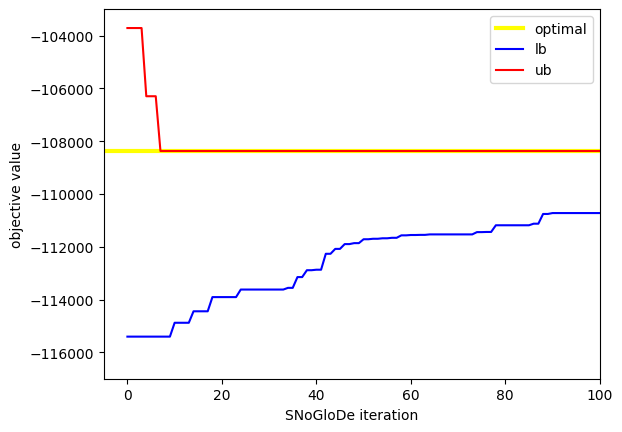

In [81]:
params.set_branching(partition_strategy = sno.Midpoint)
midpoint_solver = sno.Solver(params)
result = midpoint_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(midpoint_solver, "Midpoint Partitioning", "figures/farmer_midpoint.png")

### `ExpectedValue`

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.011               1                           * L U      -115405.56      -103716.67          11.27%    11688.888889               2
           0.022               2                           * U        -115405.56       -107530.0         7.3241%     7875.555556               3
           0.027               3           Bound           * L        -114472.22       -107530.0         6.4561%     6942.222222               2
           0.036               4                                      -114472.22       -107530.0         6.4561%     6942.222222               3
           0.046               5                           * L        -113657.41       -107530.0       

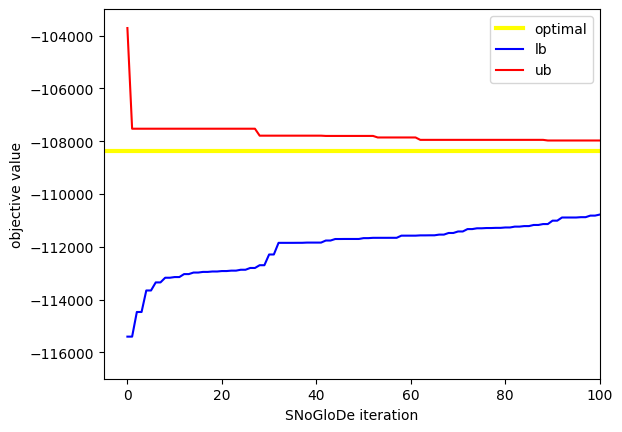

In [82]:
params.set_branching(partition_strategy = sno.ExpectedValue)
ev_solver = sno.Solver(params)
result = ev_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(ev_solver, "Expected Value Partitioning", "figures/farmer_ev.png")

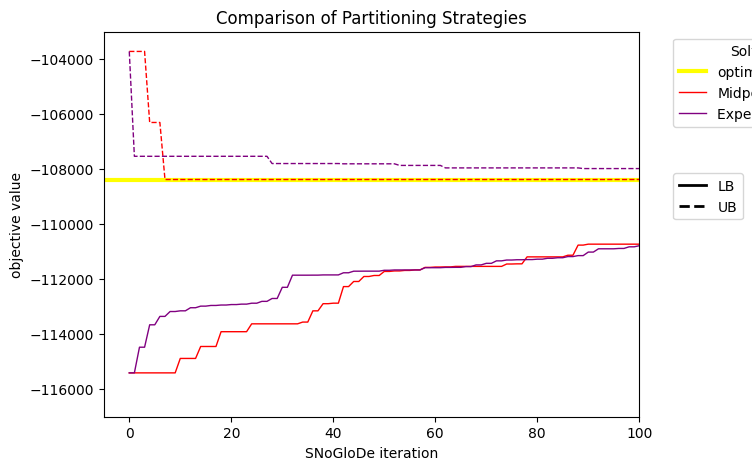

In [83]:
plot_combined_results(solvers = [midpoint_solver, ev_solver],
                      solve_names = ["Midpoint", "Expected Value"],
                      colors = ["red", "purple"],
                      title = "Comparison of Partitioning Strategies",
                      fig_name = "figures/partitioning_strategies.png")

-------------

## Lower Bounding (`LowerBounder`)

We only offer one lower bounding option - `DropNonants`, which just drops the complicating constraints and solves each of the subproblems separately. We could try and further relax the problem - let's consider an alteration to the problem. 


### Integer Farmer

For this example, we have an entirely continuous problem (i.e., $x$, $y$, and $z$ are positive reals). Let's now assume we have to make planting decisions that are now *integer*; we cannot plant 1.5 acres of wheat, it's either 1 acre or 2 acres. This can allow us to write a custom lower bounder, that further relaxes the problem by disregarding integrality.

It also helps that the optimal solution to the LP has an integral solution, so we maintain the same optimal solution!

In [84]:
def integer_subproblem_creator(scenario_name):
    """
    Based on the scenario, generates 
        1) the pyomo model
        2) the dict of complicating variable IDS : pyo.Var
        3) the list of subprob lem specific variables (pyo.Vars)
        3) probability of subproblem
    and returns as a list in this order.
    """
    name_to_yield_map = {
        "good": 1.2,
        "fair": 1.0,
        "bad": 0.8
    }
    
    # create parameters / model stored in obj for this scenario
    farmer_scenario = TwoStageFarmer(name_to_yield_map[scenario_name],
                                     integer_first_stage = True) # <- NOTE: HERE IS THE MAJOR CHANGE

    # grab the list of first stage variables
    complicating_variable_ids = {("devoted_acrege", crop): farmer_scenario.model.x[crop] \
                                for crop in farmer_scenario.planting_crops}
    
    # probability of this particular scenario occuring
    scenario_probability = 1/3

    return [farmer_scenario.model,              # pyomo model corresponding to this subproblem
            complicating_variable_ids,          # complicating varID : pyo.Var dict
            scenario_probability]               # probability of this subproblem

subproblem_names = ["good", "fair", "bad"]
integer_params = sno.SolverParameters(subproblem_names = subproblem_names,
                                      subproblem_creator = integer_subproblem_creator,
                                      lb_solver = pyo.SolverFactory("gurobi"),
                                      cg_solver = pyo.SolverFactory("gurobi"),
                                      ub_solver = pyo.SolverFactory("gurobi"))
integer_params.set_bounds_tightening(False, False)

Note the only difference between `subproblem_creator()` and `integer_subproblem_creator()` is when we create the farmer scenario model; `TwoStageFarmer` has an optional argument to enforce the complicating variables $x$ to be integer.

### Custom Lower Bounder

Next, we can implement the `CustomLowerBounder` inherited class. This class is a derived class from the `AbstractLowerBounder`. It has an `__init__()` for any extra elements we want to save per iteration, and a callback `solve_a_subproblem()` that will be invoked for *each subproblem* at *each iteration*.

In this case, if we were on the $k^{\text{th}}$ iteration, then we would call `solve_a_subproblem()` 3 times (`subproblem_name = good`, `subproblem_name = avg`, `subproblem_name = bad`). Each callback should solve the model passed, and return if the solution was feasible and whatht eobjective value is. 

In [ ]:
from typing import Optional, Tuple
from pyomo.opt import TerminationCondition, SolverStatus

class CustomLowerBounder(sno.AbstractLowerBounder):
    def __init__(self,  solver: str) -> None:
        super().__init__(solver = solver)

    def solve_a_subproblem(self, 
                           subproblem_name: str, 
                           subproblem_model: pyo.ConcreteModel, 
                           subproblem_complicating_vars: dict) -> Tuple[bool, Optional[float]]:
        """
        This must be defined in the child class.
        It must always take these inputs, to maintain fluidity within the solver.

        Parameters
        -----------
        subproblem_name : str
            String corresponding to this subproblems name
        subproblem_model : pyo.ConcreteModel
            pyomo model corresponding to this subproblem
        subproblem_complicating_vars : dict
            dictionary corresponding to this current subproblems complicating variables

        Returns
        -----------
        feasible : bool
            if the solve of the subproblem model was feasible or not
        objective : float
            objective value of the subproblem model; None if infeasible.
        """

        # RELAX INTEGERS
        subproblem_model.x["beets"].domain = pyo.NonNegativeReals
        subproblem_model.x["corn"].domain = pyo.NonNegativeReals
        subproblem_model.x["wheat"].domain = pyo.NonNegativeReals

        # solve model
        results = self.opt.solve(subproblem_model, load_solutions = False, symbolic_solver_labels=True, tee = False)
        
        # UN-RELAX INTEGERS
        subproblem_model.x["beets"].domain = pyo.Integers
        subproblem_model.x["corn"].domain = pyo.Integers
        subproblem_model.x["wheat"].domain = pyo.Integers

        # if the solution is optimal, return objective value
        if results.solver.termination_condition==TerminationCondition.optimal and results.solver.status==SolverStatus.ok:

            # load in solutions, return [feasibility = True, obj, results]
            subproblem_model.solutions.load_from(results)

            # return the value of the singular active objective.
            return True, pyo.value(subproblem_model.obj)
        
        # if the solution is not feasible, return None
        elif results.solver.termination_condition == TerminationCondition.infeasible:
            return False, None

        else:
            raise RuntimeError(f"unexpected termination_condition for lower bounding problem: {results.solver.termination_condition}")

We follow the following logic:
- Relax the integer complicating variables $x$ domains from integers $\rightarrow$ reals.
- Solve the subproblem model.
- Update the integer complicating variables $x$ domains from reals $\rightarrow$ back to integers.
- If the solution was feasible/optimal $\rightarrow$ return `True` and the objective value.
- If the solution was infeasible $\rightarrow$ return `False` and `None`.
- If the solution terminated in an unexpected way, raise an error.

All we have to do now is pass this into the parameters for the solver. In this case, it will be passed as the argument for the `params.set_bounds(lower_bounder = CustomLowerBounder)`. While we're at it, we can add the other options we want (based on what worked best before, I suppose).

### `CustomLowerBounder(AbstractLowerBounder)`

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.043               1                           * L U      -115405.56      -103479.33        11.5252%    11926.222222               2
           0.083               2                           * U        -115405.56       -108376.0         6.4863%     7029.555556               3
           0.123               3                                      -115405.56       -108376.0         6.4863%     7029.555556               4
           0.163               4                                      -115405.56       -108376.0         6.4863%     7029.555556               5
           0.168               5           Bound                      -115405.56       -108376.0       

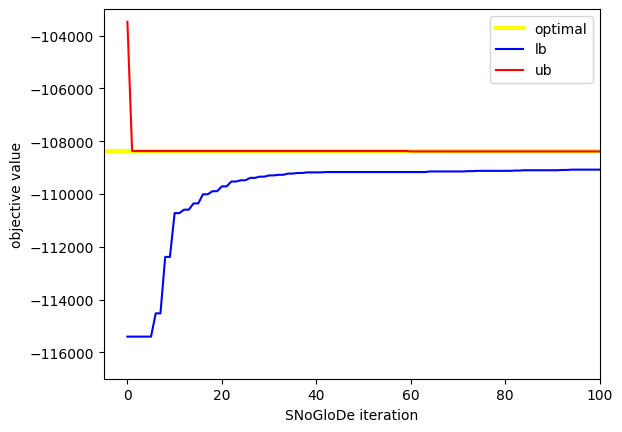

In [86]:
integer_params.set_bounders(lower_bounder = CustomLowerBounder,
                            candidate_solution_finder = sno.AverageLowerBoundSolution)
integer_params.set_queue_strategy(strategy = sno.QueueStrategy.bound)
integer_params.set_branching(selection_strategy = sno.FullStrongBranching,
                             partition_strategy = sno.Midpoint)
custom_solver = sno.Solver(integer_params)
result = custom_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(custom_solver, "CustomLowerBounder Integer First-Stage Variables", "figures/farmer_integer_first_stage.png")

### `DropNonants` (Default)

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.044               1                           * L U       -115400.0       -108390.0         6.4674%          7010.0               2
           0.103               2                                       -115400.0       -108390.0         6.4674%          7010.0               3
            0.11               3           Bound                       -115400.0       -108390.0         6.4674%          7010.0               2
           0.149               4                                       -115400.0       -108390.0         6.4674%          7010.0               3
           0.184               5                                       -115400.0       -108390.0       

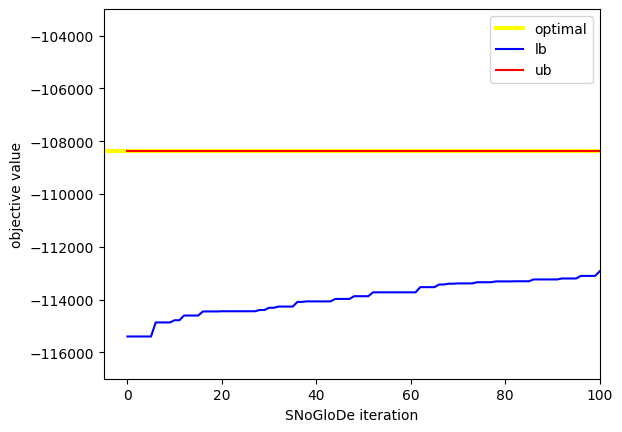

In [87]:
integer_params.set_bounders(lower_bounder = sno.DropNonants)
dropnonants_solver = sno.Solver(integer_params)
result = dropnonants_solver.solve(max_iter = 100, collect_plot_info = True, rel_tolerance=tolerance_level)
plot_results(dropnonants_solver, "DropNonants Integer First-Stage Variables", "figures/farmer_integer_first_stage.png")

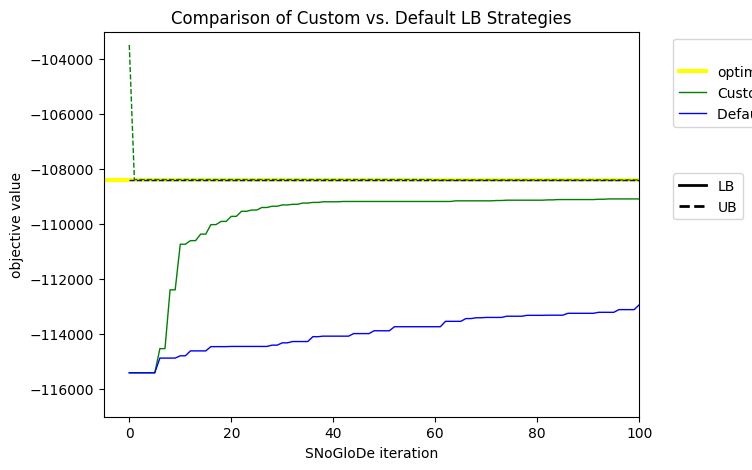

In [88]:
plot_combined_results(solvers = [custom_solver, dropnonants_solver],
                      solve_names = ["Custom", "Default (DropNonants)"],
                      colors = ["green", "blue"],
                      title = "Comparison of Custom vs. Default LB Strategies",
                      fig_name = "figures/lb_strategies.png")

Clearly, imposing problem specific information (even as simple as knowledge of integrality constraints) can make a *huge* difference in the progression of the algorithm. Customization can be significantly involved, or as simple as changing variable domains.

A word of caution: `SNoGloDe` can do a lot, but it cannot check if your lower bounding / relaxation logic is correct. If you're considering customization, double/triple check your logic. 